<h1> Training Results Analysis | MNIST </h1>

<h2> Gaussian Init - SGD</h2>

In [2]:
import sys
import os 

project_root = "/Users/janikwahrheit/Library/CloudStorage/OneDrive-Persönlich/01_Studium/01_Bachelor/Bachelorarbeit/Code"

sys.path.append(project_root)

In [3]:
import h5py
import numpy as np
import polars as pl
import numpy as np
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri, numpy2ri, default_converter
import rpy2.robjects as ro
from data.h5pydb import load_h5_as_polars_v2
import matplotlib.pyplot as plt 
import seaborn as sns 

In [4]:
path_none_sgd= r"/Users/janikwahrheit/Library/CloudStorage/OneDrive-Persönlich/01_Studium/01_Bachelor/Bachelorarbeit/Code/data/training_results/fc10_mnist_None_sgd_mnist_log.h5"
path_lasso_sgd = r"/Users/janikwahrheit/Library/CloudStorage/OneDrive-Persönlich/01_Studium/01_Bachelor/Bachelorarbeit/Code/data/training_results/fc10_mnist_lasso_sgd_mnist_log.h5"
path_hill_sgd = r"/Users/janikwahrheit/Library/CloudStorage/OneDrive-Persönlich/01_Studium/01_Bachelor/Bachelorarbeit/Code/data/training_results/fc10_mnist_hill_sgd_mnist_log.h5"


In [5]:
df_none_sgd  = load_h5_as_polars_v2(path_none_sgd)
df_lasso_sgd = load_h5_as_polars_v2(path_lasso_sgd)
df_hill_sgd = load_h5_as_polars_v2(path_hill_sgd)


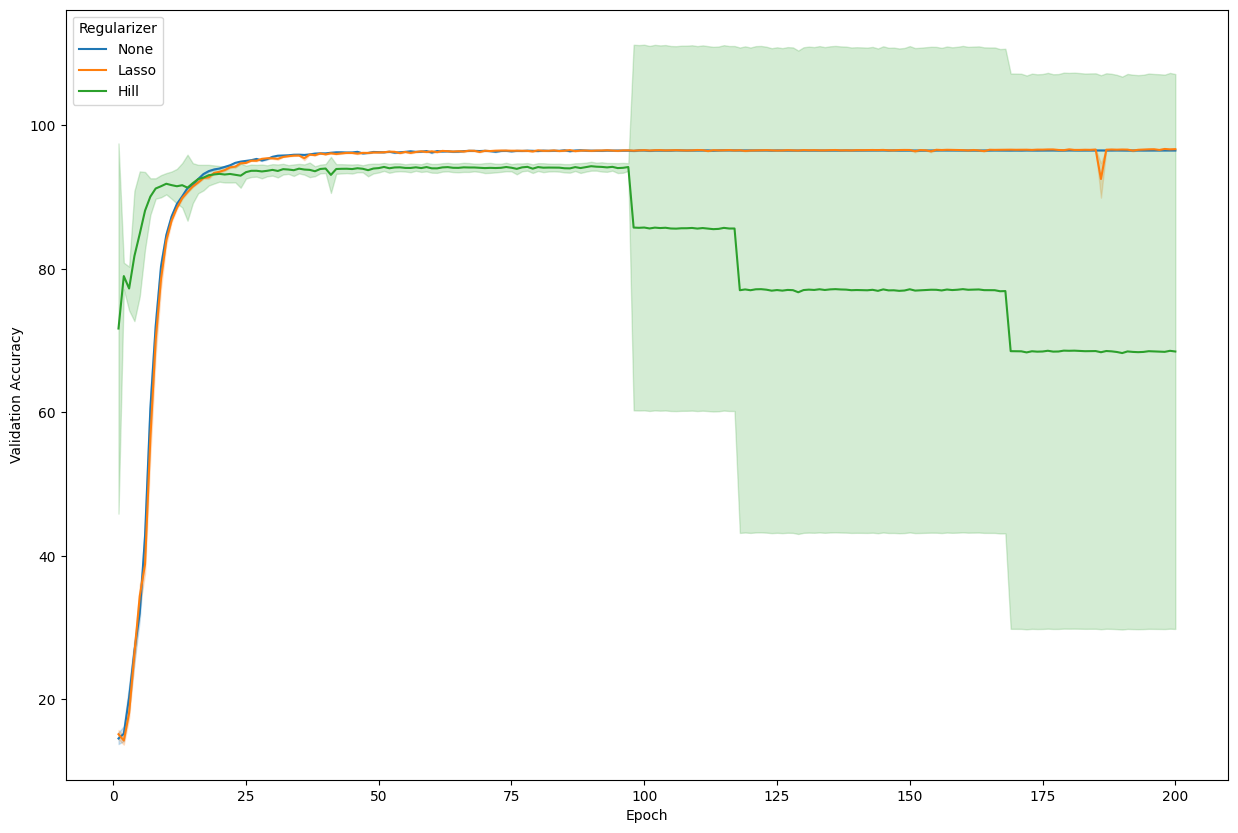

In [6]:
fig, ax = plt.subplots(figsize=(15, 10))

sns.lineplot(x="epoch", y="val_accuracy", data=df_none_sgd, label="None", ax=ax)
sns.lineplot(x="epoch", y="val_accuracy", data=df_lasso_sgd, label="Lasso", ax=ax)
sns.lineplot(x="epoch", y="val_accuracy", data=df_hill_sgd, label="Hill", ax=ax, errorbar="sd")

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy")
ax.legend(title="Regularizer")

In [7]:
df_concat = pl.concat([df_none_sgd, df_lasso_sgd, df_hill_sgd])

In [25]:
epochs = np.concatenate(([1], np.arange(25, 201, 25)))
epochs.tolist()
np.arange(25, 201, 25)

array([ 25,  50,  75, 100, 125, 150, 175, 200])

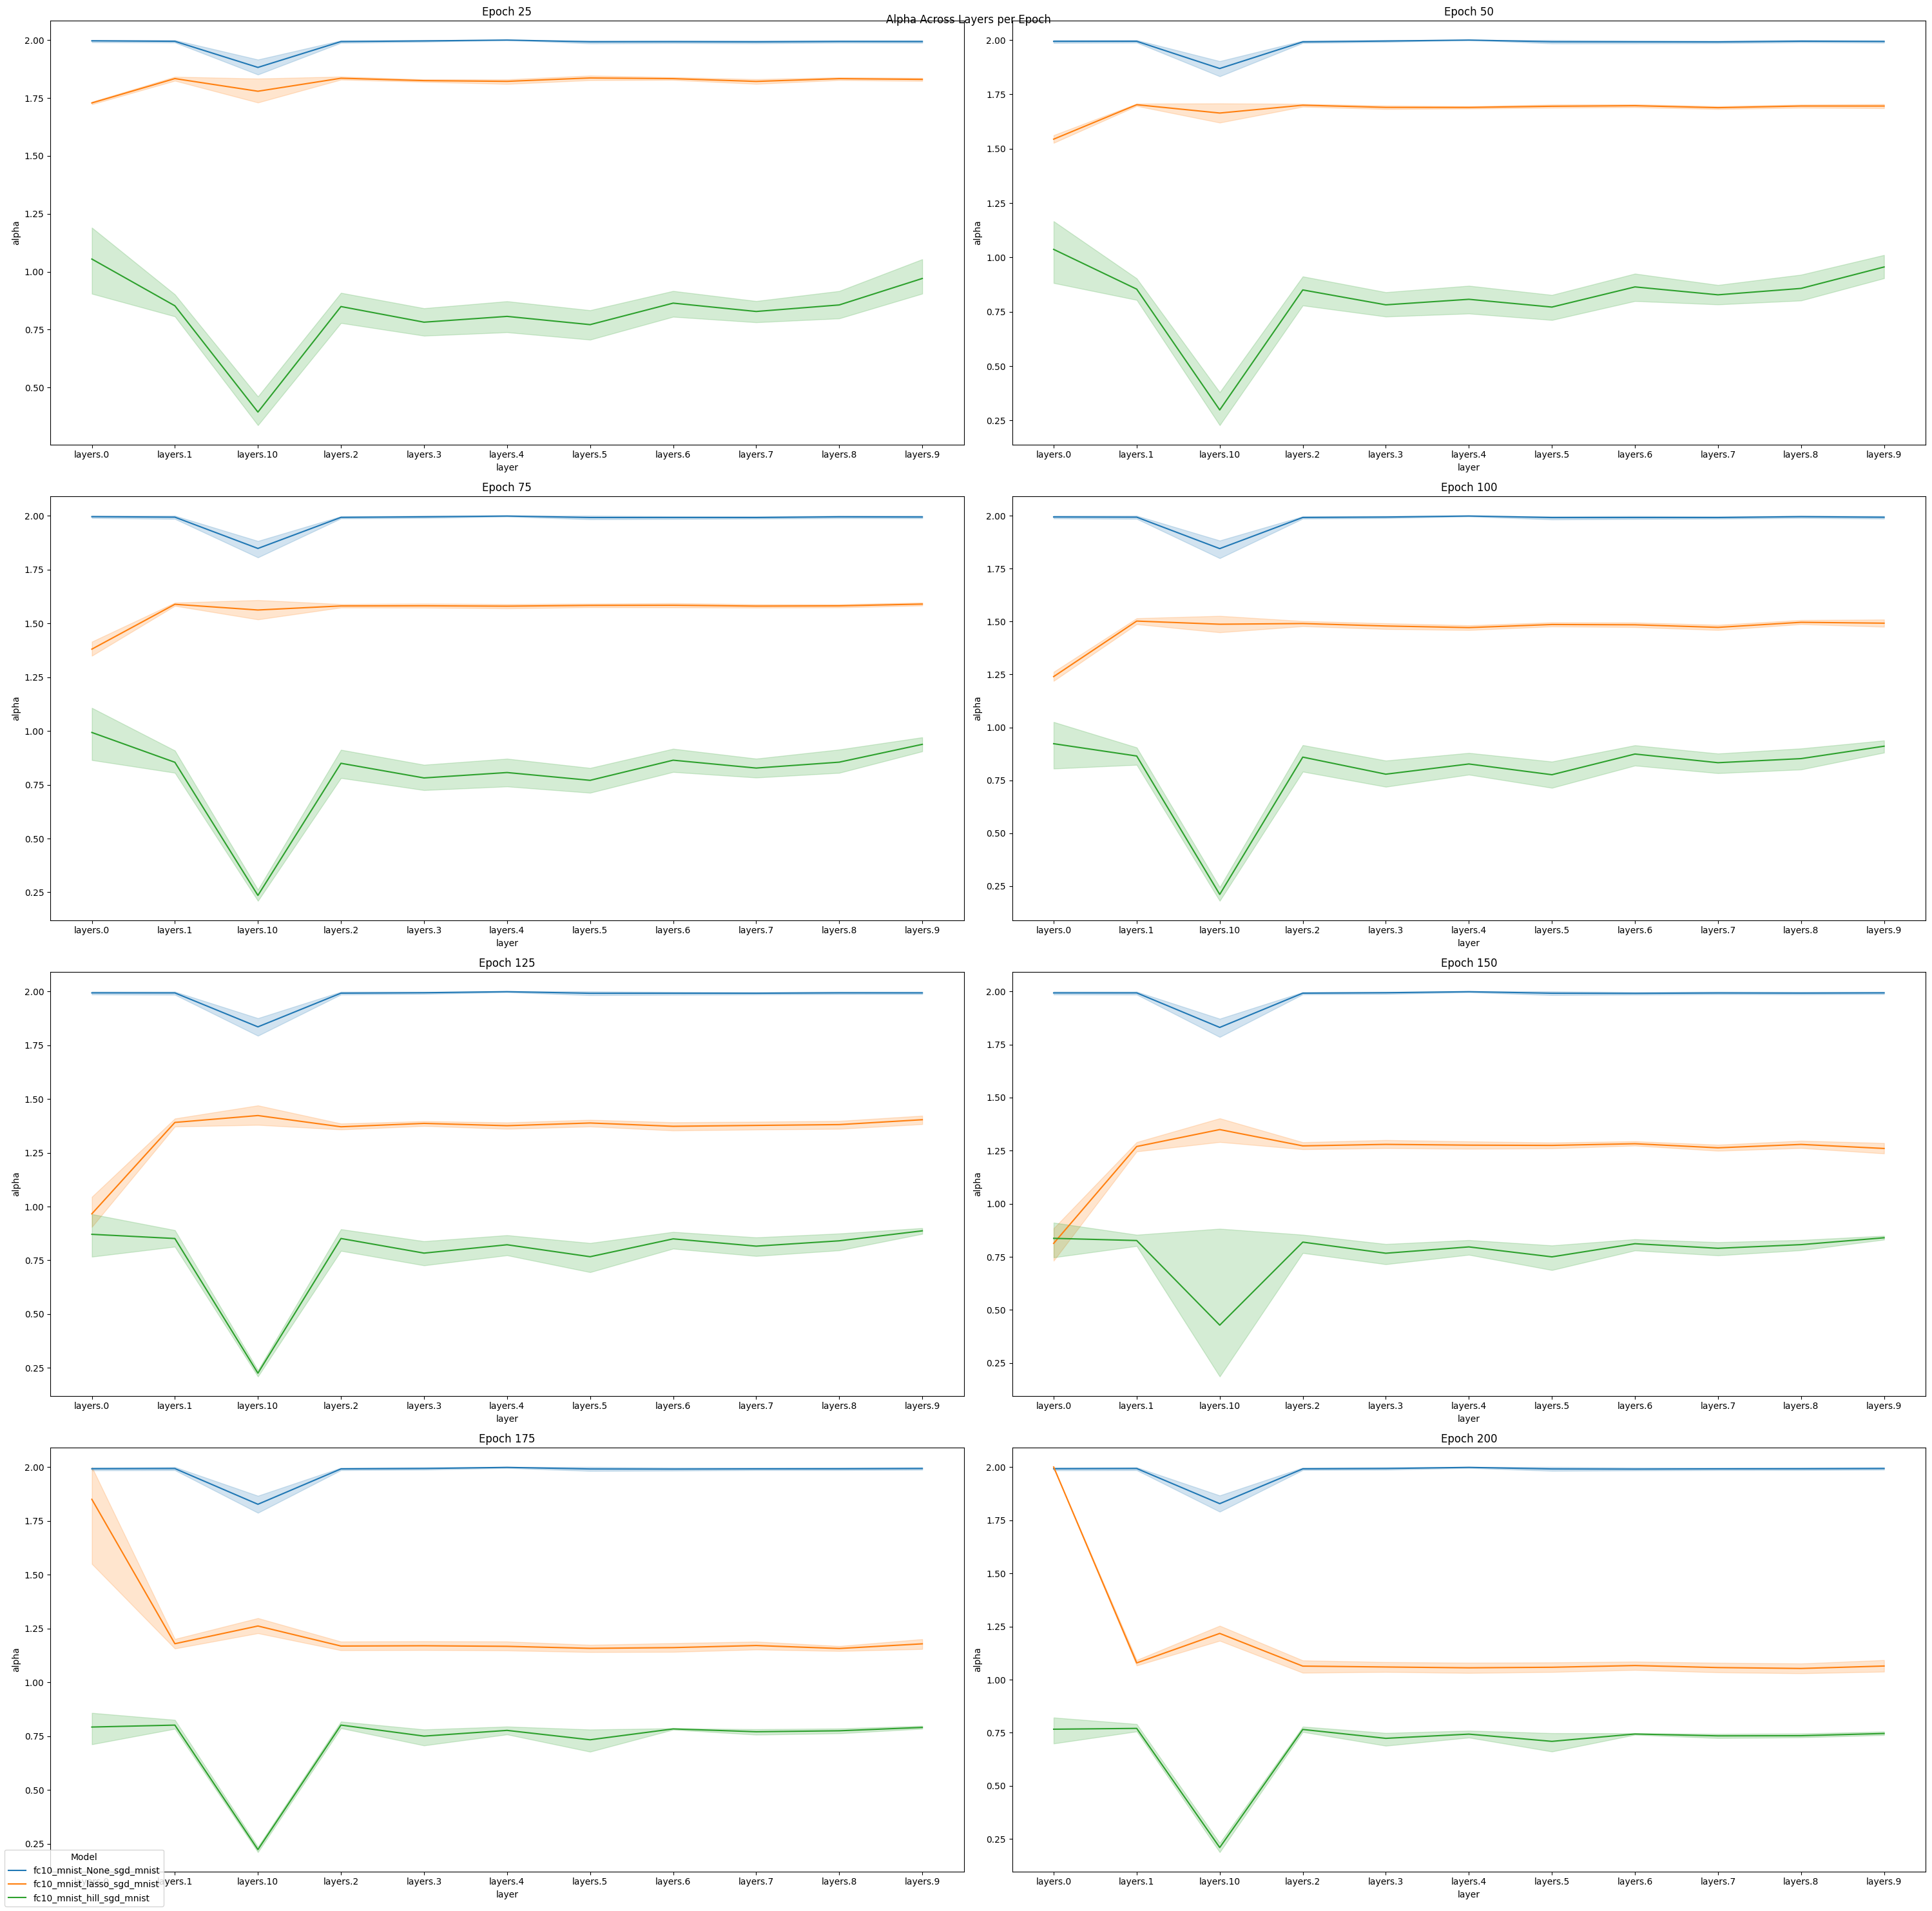

In [26]:
epochs = np.arange(25, 201, 25)

fig, axes = plt.subplots(figsize=(30, 30), ncols=2, nrows=int(len(epochs)/2))

axes = axes.flatten()
handles_labels = []

for epoch, ax in zip(epochs.tolist(), axes):

    df_epoch = df_concat.filter(
        (pl.col("epoch") == epoch)
    )

    sns.lineplot(
        data=df_epoch,
        x="layer",
        y="alpha",
        hue="model",
        ax=ax
    )

    ax.set_title(f"Epoch {epoch}")
    try:
        ax.get_legend().remove()
    except: 
        continue
    if not handles_labels:
        handles, labels = ax.get_legend_handles_labels()
        handles_labels = (handles, labels)



fig.legend(
    handles_labels[0],
    handles_labels[1],
    title="Model",
    loc="lower left",

)
fig.suptitle("Alpha Across Layers per Epoch", fontsize=12)


plt.tight_layout()
plt.show()


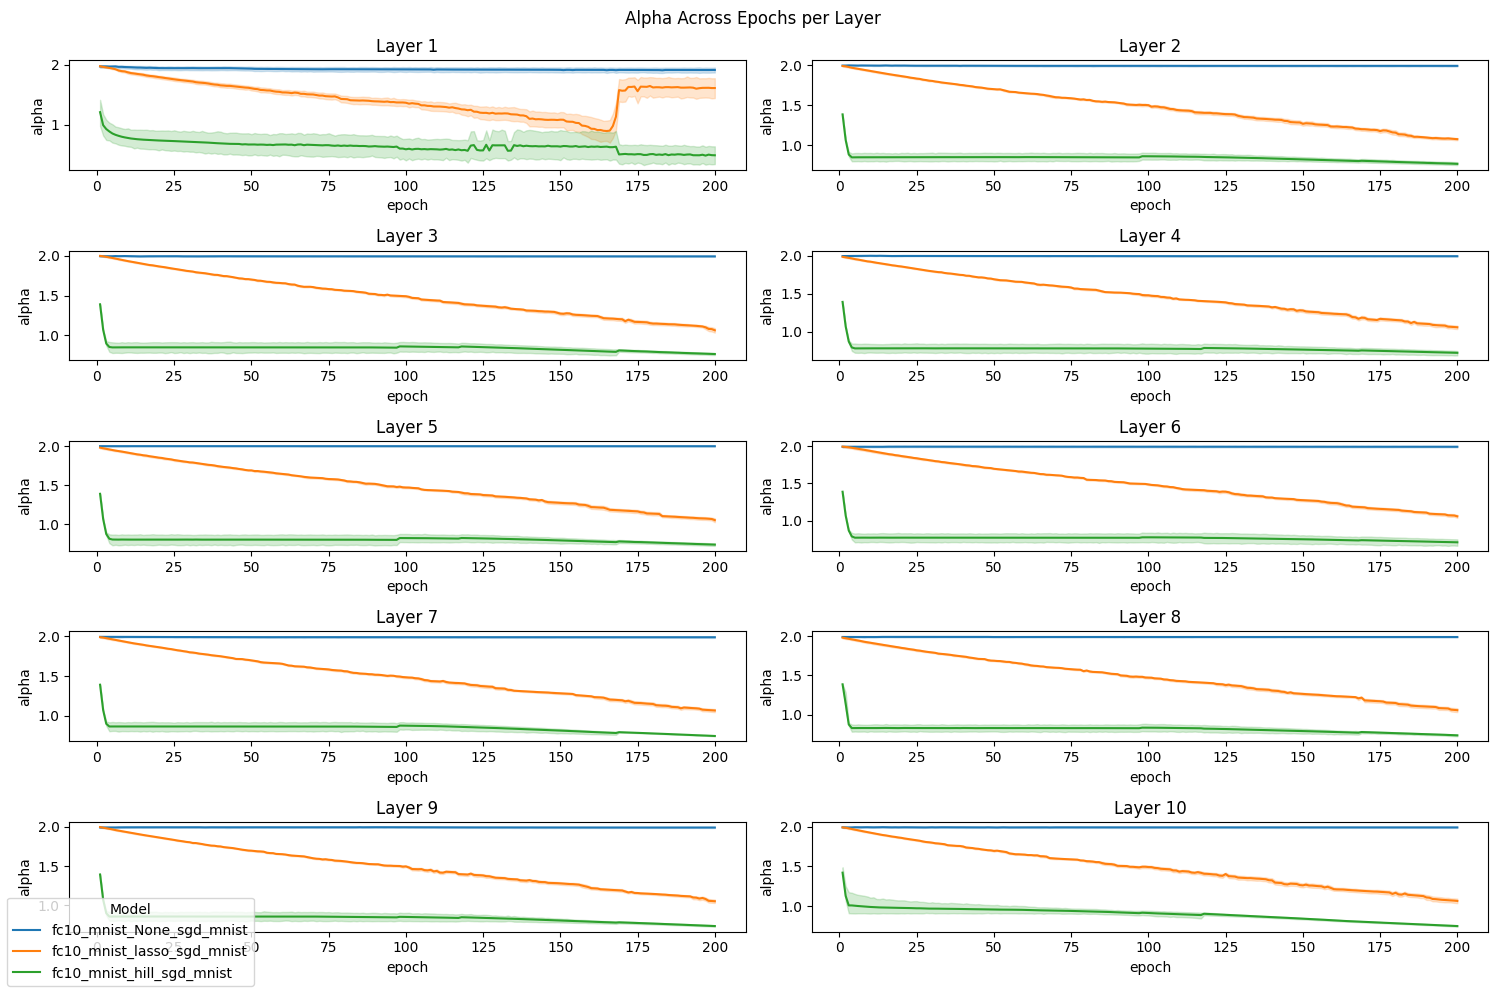

In [27]:
layers = 10

fig, axes = plt.subplots(figsize=(15, 10), ncols=2, nrows=int(layers/2))

axes = axes.flatten()
handles_labels = []

for layer, ax in zip(range(layers), axes):

    df_epoch = df_concat.filter(
        (pl.col("layer").str.slice(-1).cast(int) == layer))

    sns.lineplot(
        data=df_epoch,
        x="epoch",
        y="alpha",
        hue="model",
        ax=ax
    )

    ax.set_title(f"Layer {layer+1}")
    if not handles_labels:
        handles, labels = ax.get_legend_handles_labels()
        handles_labels = (handles, labels)
    ax.get_legend().remove()


fig.legend(
    handles_labels[0],
    handles_labels[1],
    title="Model",
    loc="lower left",

)
fig.suptitle("Alpha Across Epochs per Layer", fontsize=12)

plt.tight_layout()
plt.show()
